# Guía para el procesamiento de genomas de *Thiotrichales* 

## Objetivo
El propósito de esta guía es explica paso a paso cómo limpiar procesar los datos de genomas de *Thiotrichales* (archivos .fasta). El pipeline esta diseñado para transformar archivos crudos en una tabla final y compatible con el siguiente  [script](https://github.com/ecoevolab/thiotrichales_genomics/blob/main/grafica/grafica.R).

La meta es filtrar los datos necesarios que sirvan de input para recrear la siguiente imagen:


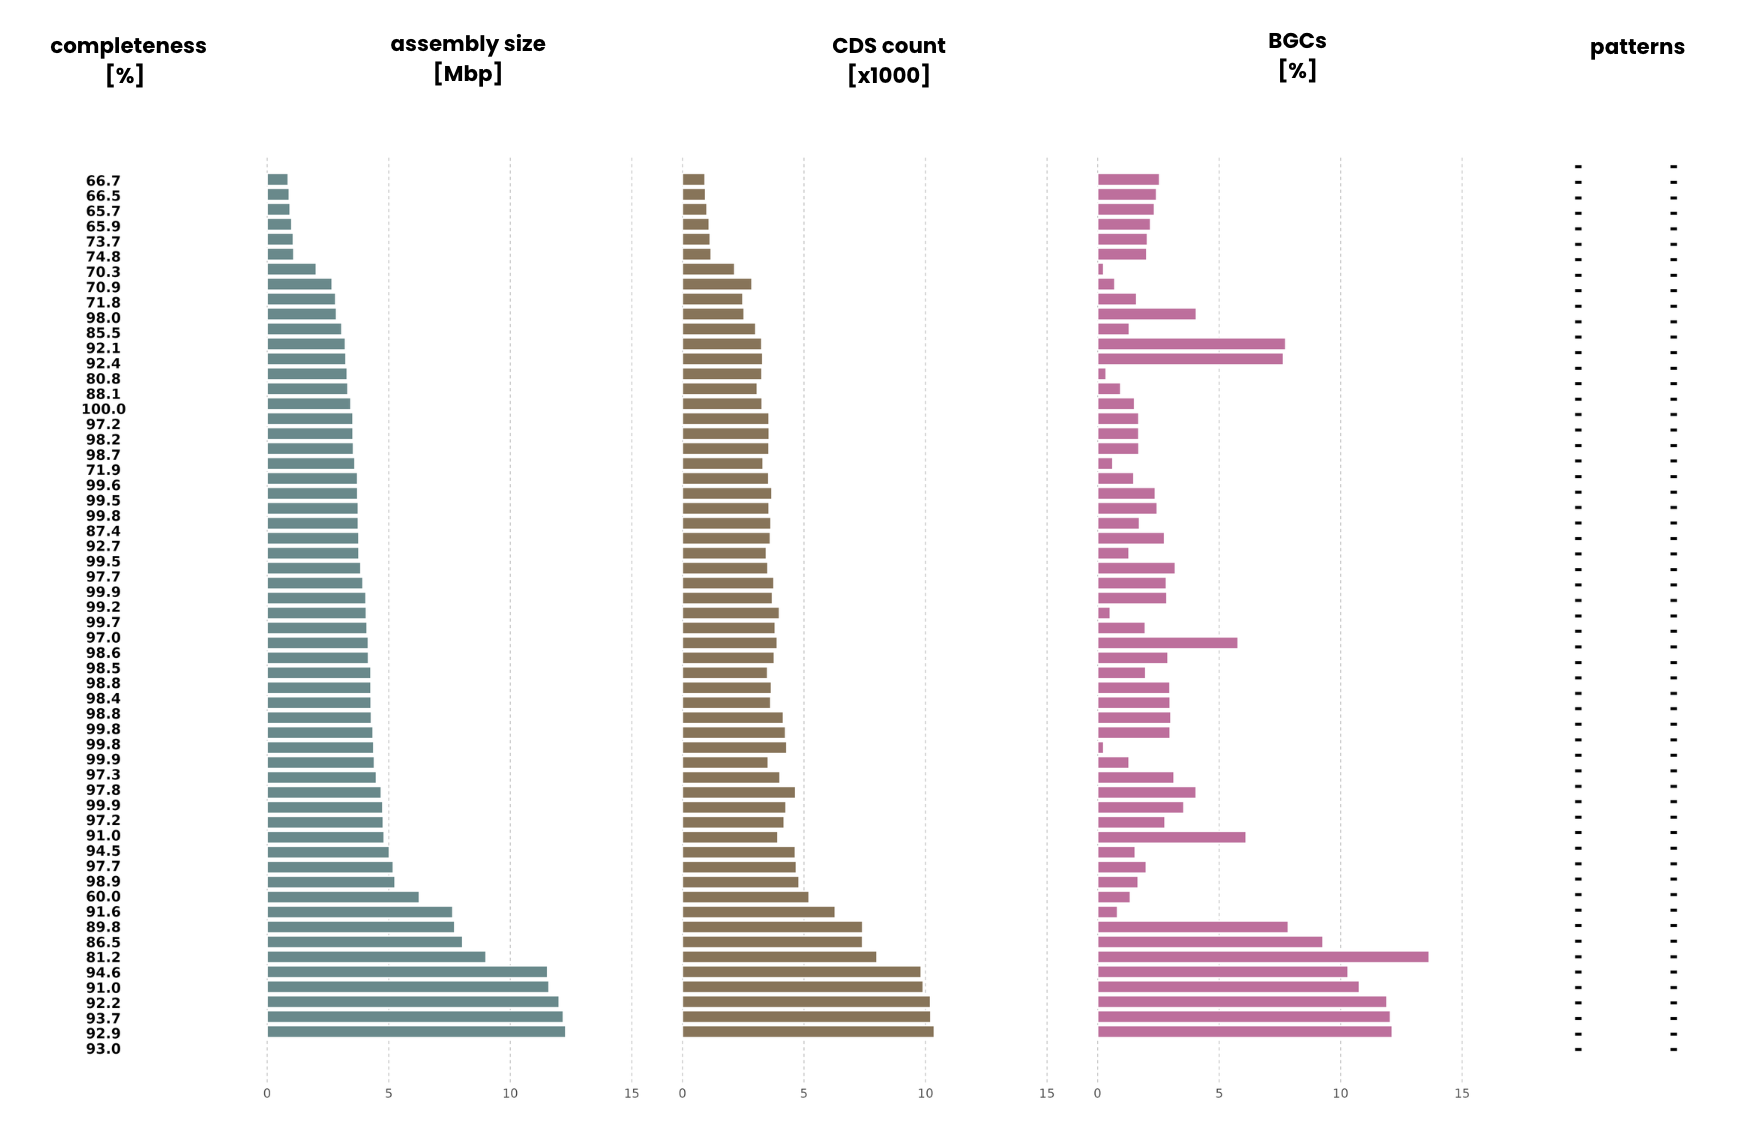


## Metodología (Cómo obtener cada columna)
Para que los datos sean compatibles con la gráfica, se necesita procesar cada genoma con las siguientes herramientas:

1. **CheckM v1.2.2:** esta herramienta nos permite saber la completitud del genoma, asi cómo la contaminación y el tamaño del genoma bacter.

   **Columnas generadas:** Completeness [%] y Assembly size [Mbp].

2. **Prokka (tmb agregar version):**  Realiza una anotación de características funcionales dentro de un genoma bacteriano (genes, proteínas, etc).

   **Columna generada:** CDS count [x1000].

3. **antiSMASH:** Herramienta especializada en la identificación de grupos de genes biosinteticos (BGCs) de metabilitos secuendarios en bacteria.

   **Columna generada:** BGCs[%].

4. **eggNOG + HMMER:** el primero es una base de datos que nos proporciona grupos de genes ortólogos, mientras que el segundo es una herramienta bioinformatica que utiliza modelos ocultos de Markov, para alinear y encontrar patrones de dominios proteícos especificos.

   **Columna generada:** patterns.



## Interpretación de la tabla final
Para facilitar el análisis de la gráfica, en esta sección se define el significado de cada columna obtenida:

- **Completeness [%]:** Indica el procentaje de completitud del genoma.
- **Assembly size [MBp]:** Es el tamaño total del genoma en Megabases
- **CDS count [x1000]:** Numero de pares de bases **PENDIENTE**
- **BGCs [%]:** Es el número de pares de bases que ocupa los Biosintetic gene cluster en el genoma, reflejado en porcentaje.
- **Paterns:** Esta compuesta por dos columnas:
  1. la primera indica si estan presentes (+) o ausentes (-) todos los genes del cluster de división celular de bacterias modelo (AGREGAR LOS GENES)
  2. La segunda columna indica si hay alguna duplicación (+) en el set de genes del elongosoma (mreD, mrdA, and rodZ) o se mantienen en su forma simple (-).

## Procesamiento de datos
### Sección 1: Control de calidad con CheckM 

El primer paso es evaluar la calidad de los genomas que tenemos. [CheckM](https://github.com/Ecogenomics/CheckM/wiki) proporciona un conjunto de herramientas para evaluar la calidad de los genomas, proporciona estimaciones de la integridad y contaminación. 


#### 1.1 ¿Cómo ejecturar CheckM?

Debido a que el análisis de múltiples genomas es una tarea que require una alta capacidad computacional, utilizamos un cluster de alto rendimiento (HPC) que utiliza el gestor de recursos [SLURM](https://slurm.schedmd.com/documentation.html) para administrar y distribuir las tareas en nodos de procesamiento.

Para ejecutar **CheckM v1.2.2** (que estaba previamente instalado) utilizamos el siguiente script:

NOTA: este script tiene que pegarse en un editor de texto como `nano`.



```bash
#!/bin/bash
#SBATCH --job-name=checkm_thiotrichales     #nombre del job
#SBATCH --output=checkm_thiotrichales.log   #donde se va a guardar el proceso
#SBATCH --error=checkm_thiotrichales.error  #donde se van a guardar los errores
#SBATCH --nodes=1                           #nodos que se van a usar
#SBATCH --ntask=10                          #procesadores para trabajar en paralelo (CPUs)
#SBATCH --mem=32G                           #cuanta memoria RAM se va a usar
#SBATCH --time=120:00:00                    #tiempo limite de ejecucion

date
echo "====Starting checkm Analysis===="

eval "$(conda shell.bash hook)"  
 
conda activate checkm                      #se activa el entorno donde esta instalado CheckM

INPUT_DIR="ruta/donde/estan/los/genomas/de/input"
OUTPUT_DIR="ruta/donde/se/van/a/guardar/los/resultados"

mkdir -p "$OUTPUT_DIR"
checkm lineage_wf \
    -x fna \
    "$INPUT_DIR" \
    "$OUTPUT_DIR" \
    -t 10 \
    --tab_table \
    -f "$OUTPUT_DIR/resultados_checkm.tsv"

echo "==== Analisis terminado con exito ===="
date
```

Una vez terminado solo debe mandarse a la cola de procesamiento, para hacerlo se puede hacer como el siguiente comando:

```bash
sbatch nombre_del_job.sh 
```

#### 1.2 Filtrado de calidad y selección de genomas

Luego de obtener el output de checkm, el siguiente paso es filtrar los genomas, es decir, elegir aquellos que tengan la mejor calidad y con menos contaminación. Para este trabajo, utilizamos los siguientes umbrales (los cuales son arbitrarios para el tipo de estudio que se este queriendo realizar).

- **Completitud (Completeness)** > 50%
- **Contaminación (Contamination)** < 30%

Para realizar esto, lo primero es entrar a la carpeta de resultados de checkm, seguidamente entrar a la subcarpeta `storage` y  visualizar el archivo `bin_stats_ext.tsv`, que se verá algo así: 


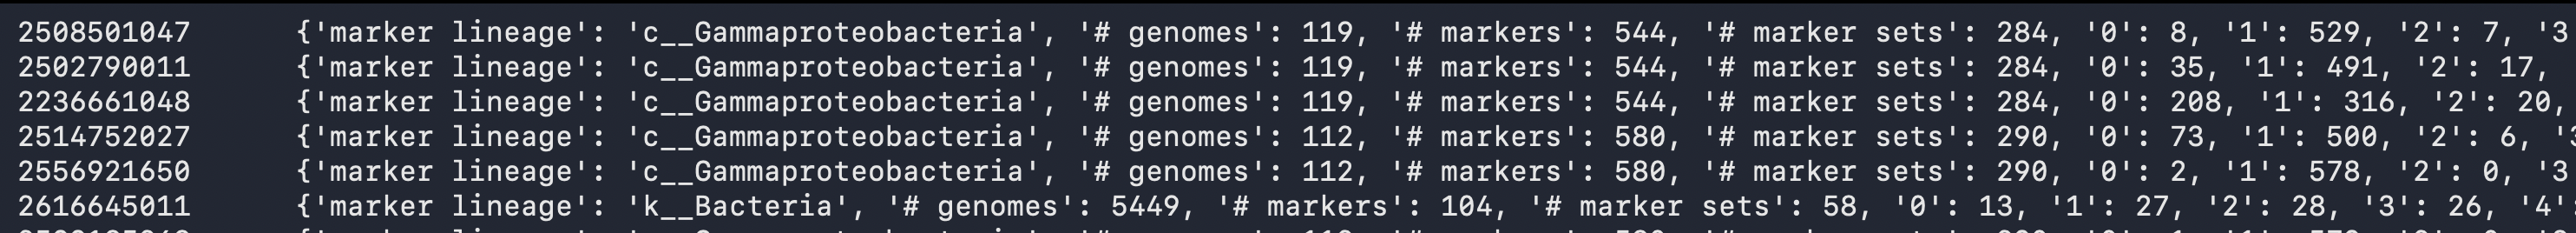

Las columnas que nos interesan son las siguientes:
- **Completeness**
- **Contamination**
- **Assembly size** (se encuentra en otro archivo y se describe más adelante)

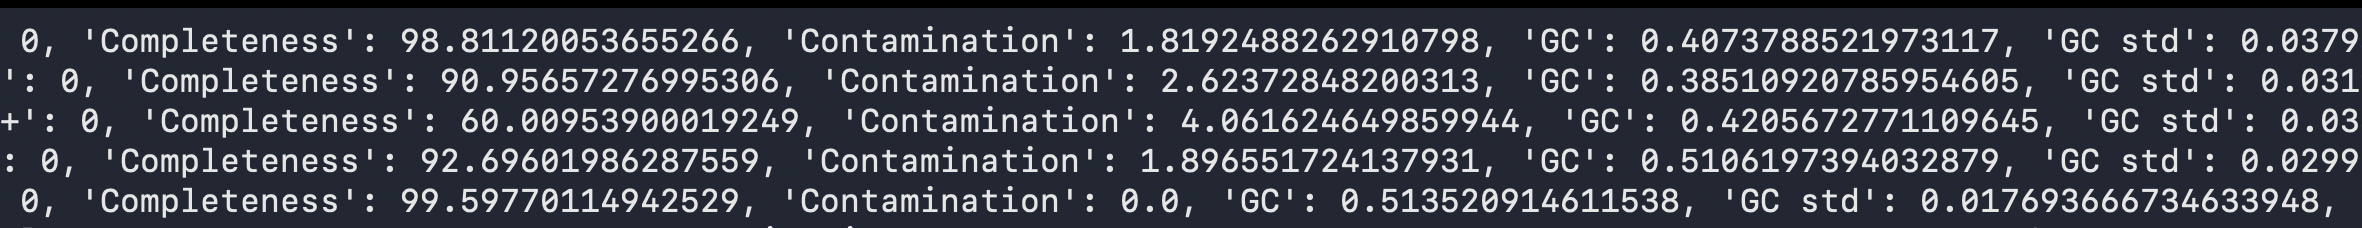

Una estrategia eficiente para filtrar la columna Completeness consiste en pre-seleccionar aquellos genomas que cumplen con el requisito de completitud (>50%). Es decir, obtener primero los IDs de estas muestras y luego filtrar los datos como conjunto. Lo podemos hacer mediante el siguiente comando.

```bash
awk -F "[:,]" '$22 > 50 && $24 < 30 {print $1 "\t" $22 "\t" $24}' bin_stats_ext.tsv | awk '{print $1 "\t" $(NF-1) "\t" $NF}' > output.txt
```

Ya que tengamos el archivo output.txt, vamos a ver tres columnas: la primera tiene el ID de los genomas, la segunda el porcentaje de completitud y la tercera el de contaminación. El formato es el siguiente:

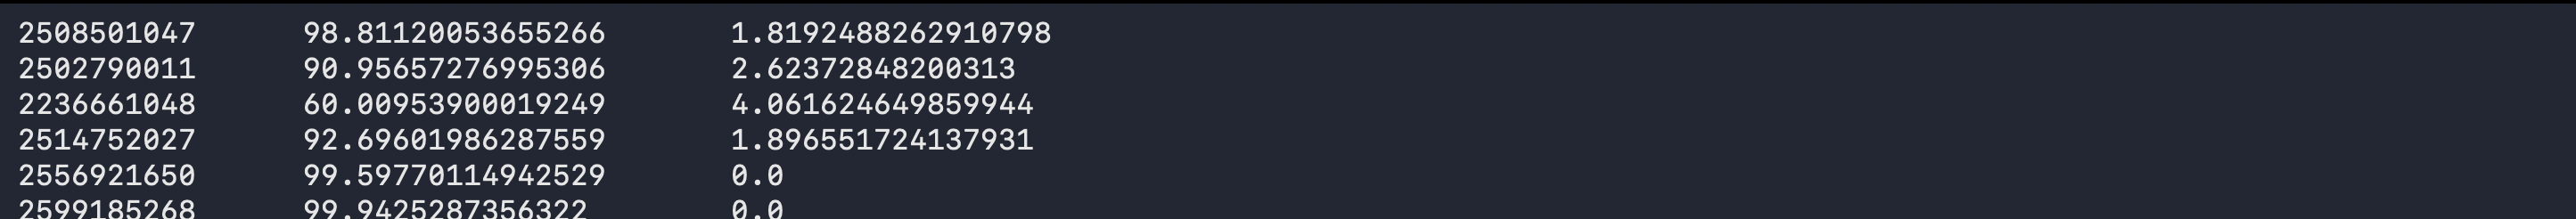

Ya con los IDs de los genomas que pasaron el filtro de calidad, lo que sigue es extraer solo esa primera columna y guardarla en un archivo nuevo:

```bash
awk '{print $1}' output.txt  > ID.txt
```

Con este archivo ID.txt, ya podemos sacar el **Assembly size** de `bin_stats.analyze.tsv`, que tiene este formato:

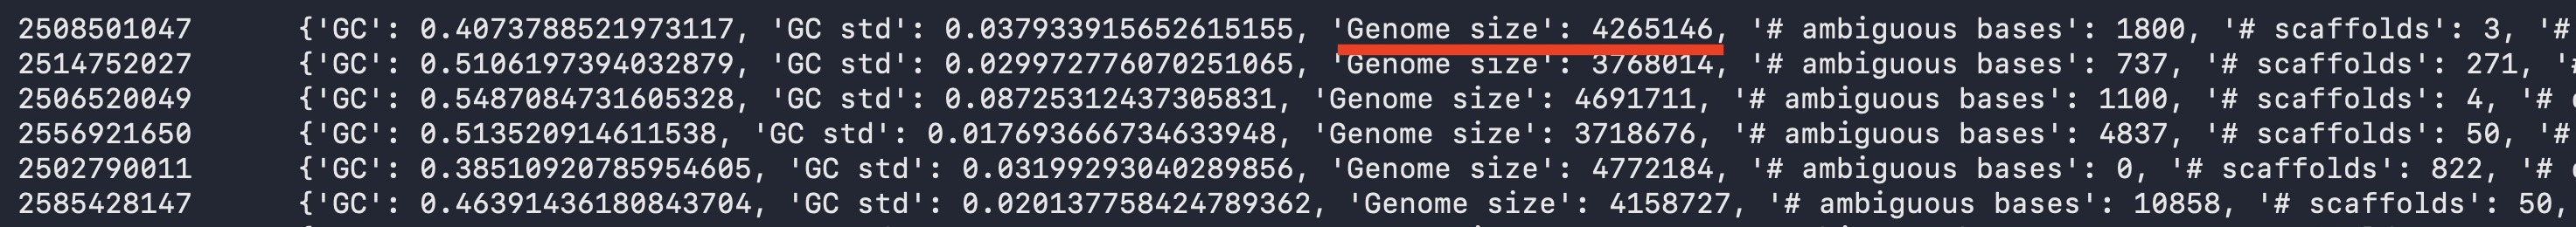


Ahora, para extraer los datos de los genomas que guardamos en ID.txt y obtener su tamaño (Genome size), usamos:

```bash
grep -F -w -f ID.txt bin_stats.analyze.tsv | awk -F "[:,]" '{gsub(/\{.GC./, "", $0); print $1, $5, $6}' > Genome_size.txt
```
El resultado se verá algo así:

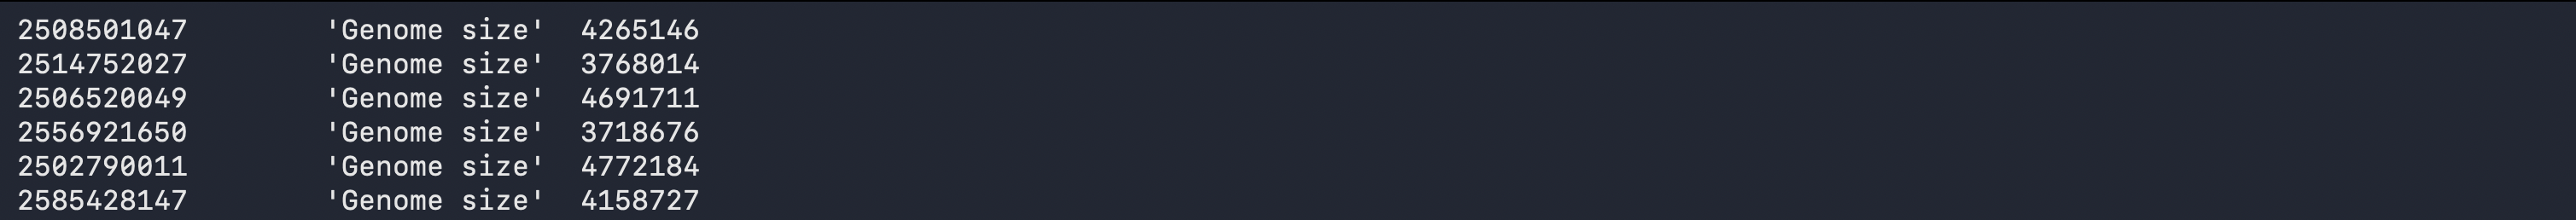

Para que sea más fácil de leer, vamos a ordenar los genomas de menor a mayor según su tamaño:

```bash
awk '$1=$1' Genome_size.txt | sort -k4 -n > Genome_size_sorted.txt

```

Ahora que tenemos los genomas ordenados por tamaño, vamos a usar ese mismo orden para todos nuestros datos. Para que las filas coincidan de aquí en adelante, actualizamos el archivo **ID.txt** usando el orden de **Genome_size_sorted.txt**:

```bash
awk '{print $1}' Genome_size_sorted.txt > ID.txt
```

Hacemos lo mismo con el archivo output.txt. Vamos a reorganizarlo para que los datos de completitud y contaminación sigan el mismo orden de los genomas que acabamos de establecer:

```bash
 awk 'NR==FNR {a[$1]=$0; next} $1 in a {print a[$1]}' output.txt ID.txt > comp_con.txt
```

***Nota**: se recomienda mover todos los archivos filtrados anteriormente a otro directorio y no trabajar en la carpeta `storage`*

### 1.3 Archivos de entrada para la gráfica (Completeness y Assembly size)

En este punto ya tenemos listos los archivos clave: `ID.txt`, `Genome_size_sorted.txt` y `comp_con.txt`. Estos contienen la información necesaria para las primeras columnas de nuestra gráfica. Además, el archivo `ID.txt` nos servirá como guía para mantener el mismo orden de los genomas en los siguientes pasos.


El primer paso de esta sección es extraer los valores del completenes que utilizaremos para alimentar la primera columna de la gráfica.
Actualmente el archivo `comp_con.txt` esta organizado en tres columnas:

- identificador del genoma (ID).
- Completeness
- Contamination

Sin embargo, para que el [script](https://github.com/ecoevolab/thiotrichales_genomics/blob/main/grafica/grafica.R) funcione corectamente, requerimos un archivo de entrada que contenga unicamente los valores númericos del Completeness y dado que el [script](https://github.com/ecoevolab/thiotrichales_genomics/blob/main/grafica/grafica.R) esta diseñado para trabajar con archivos en formato **.csv**, vamos a extraer unicamente la segunda columna del archivo comp_con.txt` y guardar la información en un nuevo archivo que nos servira como *input* para el análisis. 

La extracción se puede realizar de la siguiente forma:

```bash
awk '{print $2}' comp_con.txt > input_Completeness.csv
```


El segundo paso consiste en obtener los datos del tamaño de los genomas para la siguiente columna de la gráfica. Para esto, utilizaremos el archivo `Genome_size_sorted.txt`, el cual contiene dos columnas:

- identificador del genoma (ID).
- Genome size 

Al igual que hicimos con el completeness, filtraremos únicamente la segunda columna donde se encuentran los valores numéricos. Guardaremos este resultado en un nuevo archivo con formato **.csv**.

Para generar este archivo de entrada, utilizaremos el siguiente comando:

```bash
awk '{print $4}' Genome_size_sorted.txt > input_genome_size.csv

```

Con estos pasos, ya tenemos listos los dos archivos de entrada (inputs) necesarios para generar las primeras columnas de nuestra gráfica. 

La siguiente etapa es utilizar la herramienta **Prokka**.

## Sección 2: Anotación del genoma con Prokka